In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
image = cv2.imread("image.png")
print(image.shape)
translation_matrix = np.float32([[1, 0, 100], [0, 1, 50]])

translated_image = cv2.warpAffine(image, translation_matrix, (image.shape[1], image.shape[0]))

print(translated_image.shape)

(876, 1223, 3)
(876, 1223, 3)


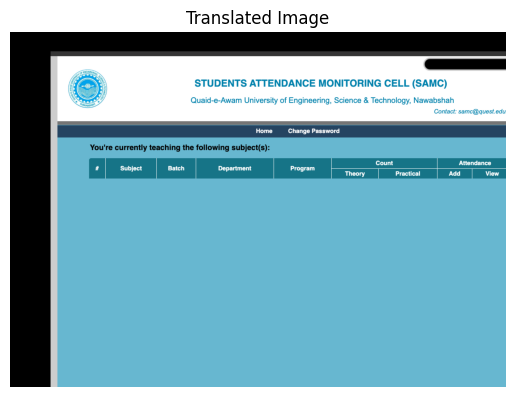

In [3]:
plt.imshow(cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB))
plt.title("Translated Image")
plt.axis("off")
plt.show()

# Task 1: Experiment with Different Translations

This section explores various translation transformations including positive and negative shifts.

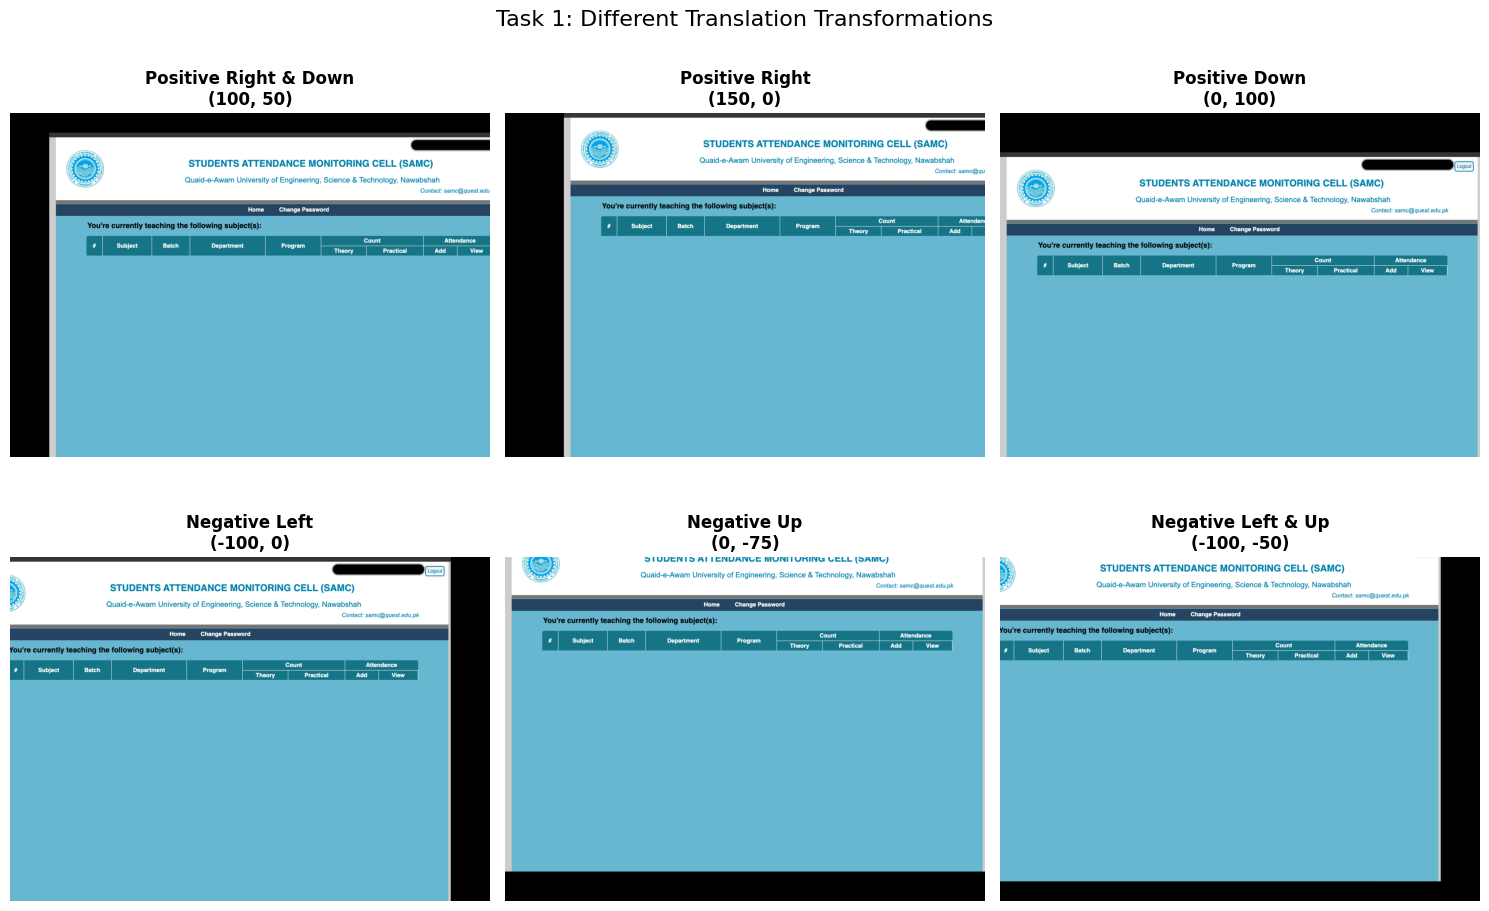

Translation experiments completed!


In [4]:
# Create a figure to display different translations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task 1: Different Translation Transformations', fontsize=16)

# Define different translation matrices
translations = [
    ("Positive Right & Down\n(100, 50)", np.float32([[1, 0, 100], [0, 1, 50]])),
    ("Positive Right\n(150, 0)", np.float32([[1, 0, 150], [0, 1, 0]])),
    ("Positive Down\n(0, 100)", np.float32([[1, 0, 0], [0, 1, 100]])),
    ("Negative Left\n(-100, 0)", np.float32([[1, 0, -100], [0, 1, 0]])),
    ("Negative Up\n(0, -75)", np.float32([[1, 0, 0], [0, 1, -75]])),
    ("Negative Left & Up\n(-100, -50)", np.float32([[1, 0, -100], [0, 1, -50]])),
]

# Apply translations and display
for idx, (title, trans_matrix) in enumerate(translations):
    row = idx // 3
    col = idx % 3
    
    # Apply the translation
    trans_img = cv2.warpAffine(image, trans_matrix, (image.shape[1], image.shape[0]))
    
    # Convert BGR to RGB and display
    axes[row, col].imshow(cv2.cvtColor(trans_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(title, fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Translation experiments completed!")

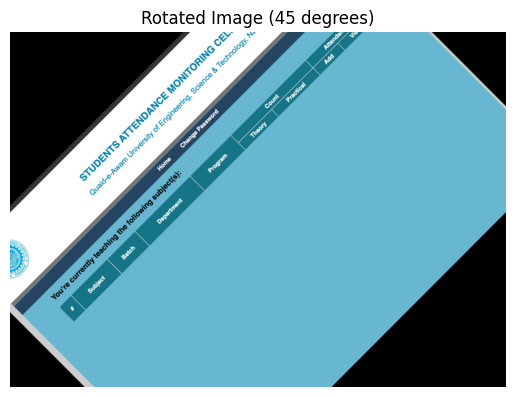

In [5]:
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))

plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image (45 degrees)")
plt.axis("off")
plt.show()

# Task 2: Explore Rotation, Scaling, and Shearing Transformations

This section explores additional affine transformations including rotation, scaling, and shearing.

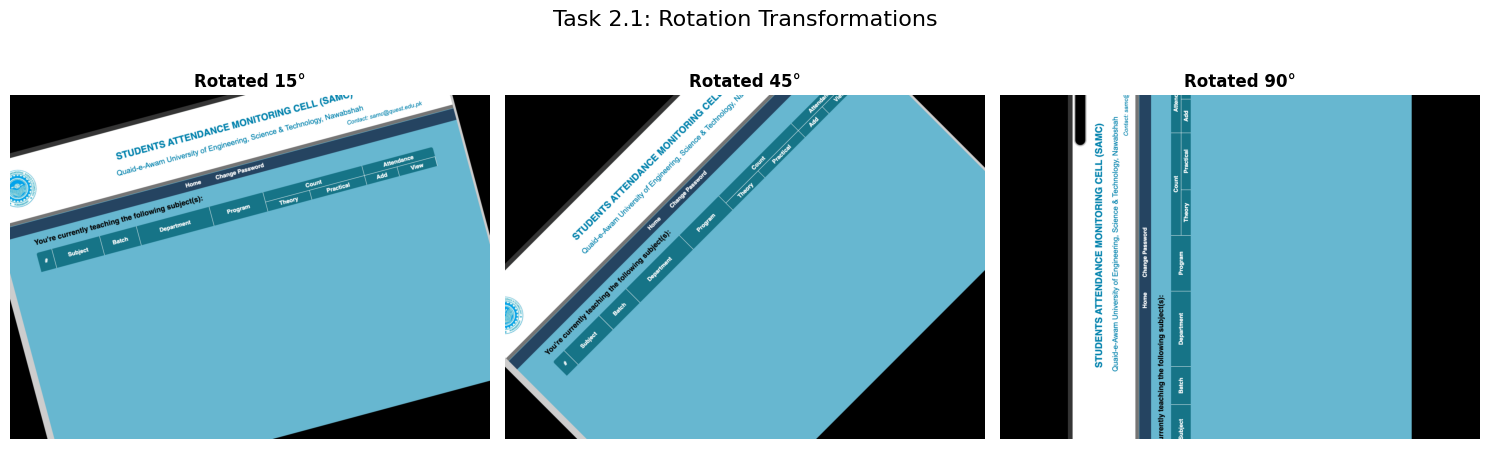

Rotation transformations completed!


In [6]:
# Task 2.1: Rotation Transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Task 2.1: Rotation Transformations', fontsize=16)

h, w = image.shape[:2]
center = (w // 2, h // 2)

# Different rotation angles
angles = [15, 45, 90]

for idx, angle in enumerate(angles):
    # Get rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # Apply rotation
    rotated_img = cv2.warpAffine(image, rotation_matrix, (w, h))
    
    # Display
    axes[idx].imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Rotated {angle}°', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Rotation transformations completed!")

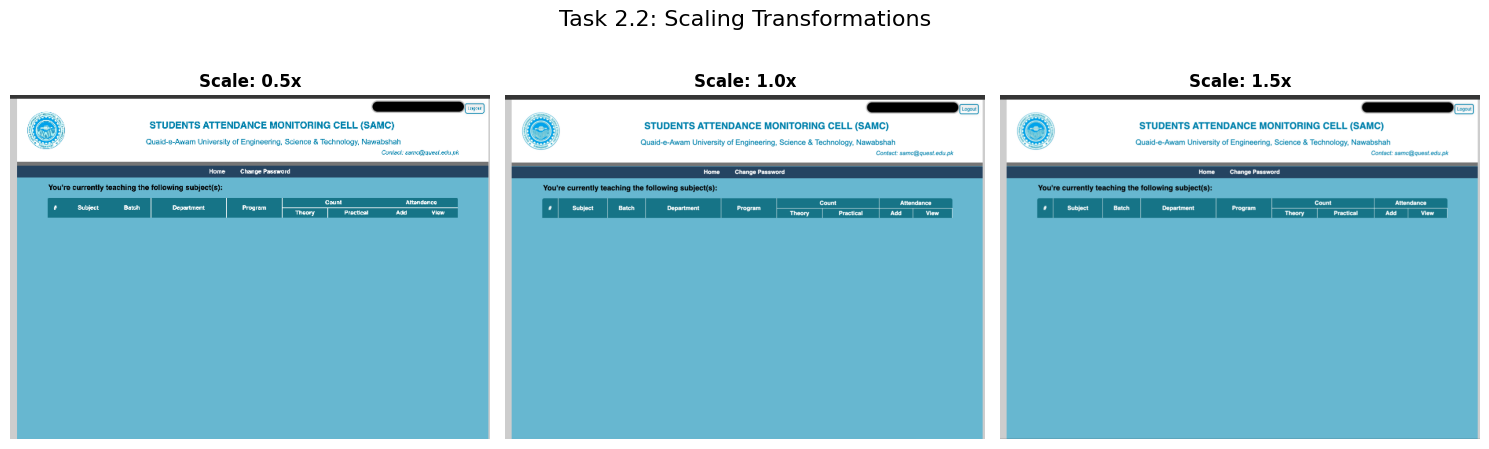

Scaling transformations completed!


In [7]:
# Task 2.2: Scaling Transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Task 2.2: Scaling Transformations', fontsize=16)

# Different scale factors
scales = [0.5, 1.0, 1.5]

for idx, scale in enumerate(scales):
    # Create scaling matrix (2x3)
    scaling_matrix = np.float32([[scale, 0, 0], [0, scale, 0]])
    
    # Apply scaling
    scaled_img = cv2.warpAffine(image, scaling_matrix, (int(w * scale), int(h * scale)))
    
    # Display
    axes[idx].imshow(cv2.cvtColor(scaled_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Scale: {scale}x', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Scaling transformations completed!")

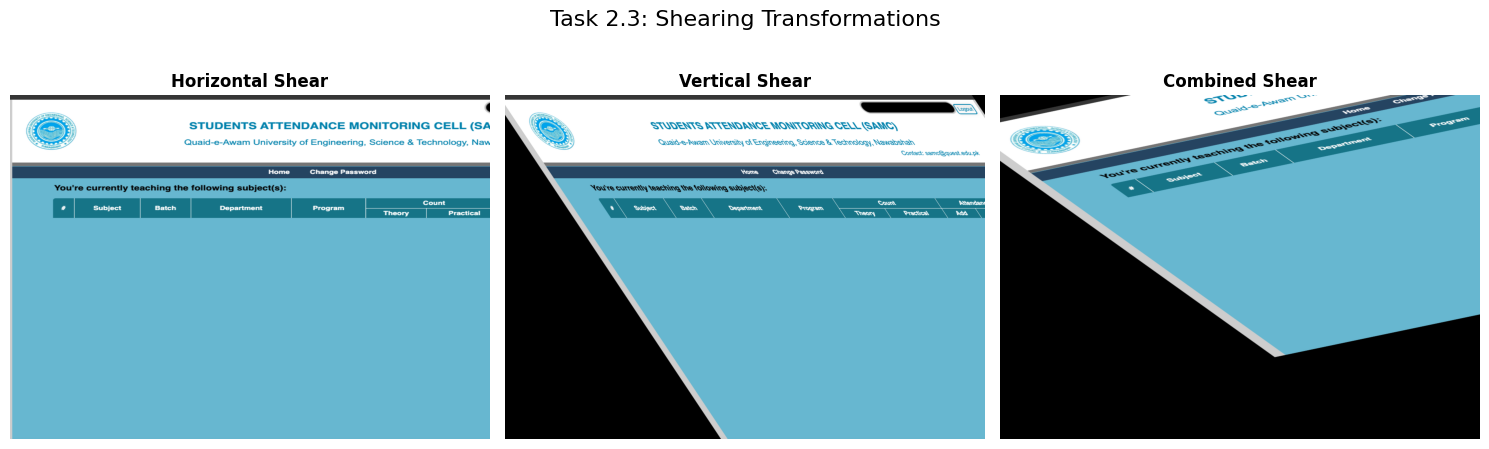

Shearing transformations completed!


In [9]:
# Task 2.3: Shearing Transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Task 2.3: Shearing Transformations', fontsize=16)

# Define three corner points of the original image
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])

# Define the transformed corner points (shearing effects)
shears = [
    ("Horizontal Shear", np.float32([[50, 50], [250, 50], [50, 200]])),
    ("Vertical Shear", np.float32([[50, 50], [200, 50], [150, 200]])),
    ("Combined Shear", np.float32([[10, 100], [250, 50], [150, 200]])),
]

for idx, (title, pts2) in enumerate(shears):
    # Get shearing matrix
    shear_matrix = cv2.getAffineTransform(pts1, pts2)
    
    # Apply shearing
    sheared_img = cv2.warpAffine(image, shear_matrix, (w, h))
    
    # Display
    axes[idx].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Shearing transformations completed!")

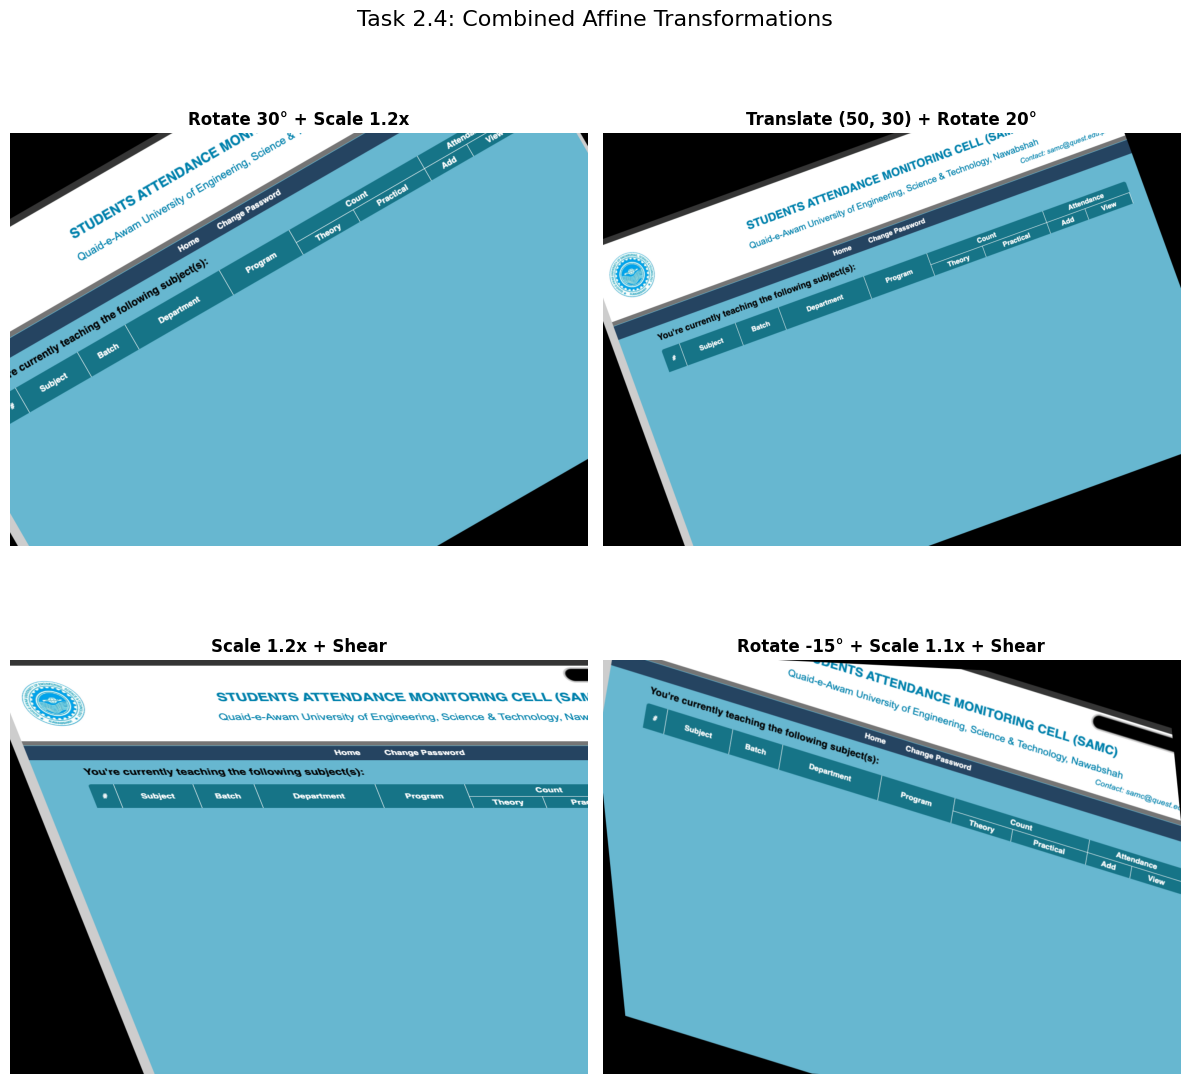

Combined transformations completed!


In [10]:
# Task 2.4: Combined Transformations
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Task 2.4: Combined Affine Transformations', fontsize=16)

# Transformation 1: Rotate + Scale
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 30, 1.2)
combined1 = cv2.warpAffine(image, rotation_matrix, (w, h))
axes[0, 0].imshow(cv2.cvtColor(combined1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Rotate 30° + Scale 1.2x', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Transformation 2: Translate + Rotate
translation_matrix = np.float32([[1, 0, 50], [0, 1, 30]])
trans_img = cv2.warpAffine(image, translation_matrix, (w, h))
rotation_matrix2 = cv2.getRotationMatrix2D(center, 20, 1.0)
combined2 = cv2.warpAffine(trans_img, rotation_matrix2, (w, h))
axes[0, 1].imshow(cv2.cvtColor(combined2, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Translate (50, 30) + Rotate 20°', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Transformation 3: Scale + Shear
scaling_matrix = np.float32([[1.2, 0, 0], [0, 1.2, 0]])
scaled = cv2.warpAffine(image, scaling_matrix, (int(w * 1.2), int(h * 1.2)))
pts1_combined = np.float32([[50, 50], [200, 50], [50, 200]])
pts2_combined = np.float32([[20, 50], [220, 50], [80, 200]])
shear_matrix = cv2.getAffineTransform(pts1_combined, pts2_combined)
combined3 = cv2.warpAffine(image, shear_matrix, (w, h))
axes[1, 0].imshow(cv2.cvtColor(combined3, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Scale 1.2x + Shear', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Transformation 4: All combined
rotation_matrix3 = cv2.getRotationMatrix2D(center, -15, 1.1)
combined4 = cv2.warpAffine(image, rotation_matrix3, (w, h))
translation_final = np.float32([[1, 0.1, -30], [0.05, 1, -20]])
combined4 = cv2.warpAffine(combined4, translation_final, (w, h))
axes[1, 1].imshow(cv2.cvtColor(combined4, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Rotate -15° + Scale 1.1x + Shear', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Combined transformations completed!")

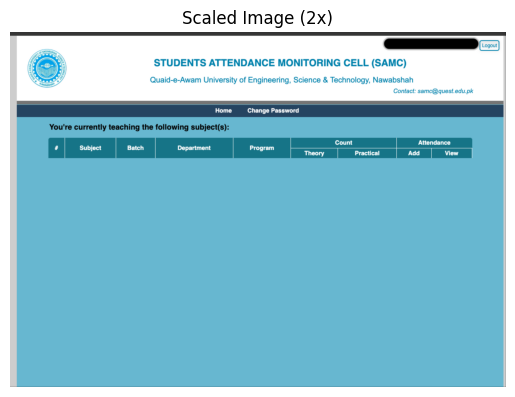

Scaling transformation completed!


In [11]:
scaling_matrix = cv2.getRotationMatrix2D((0,0), 0, 2)

scaled_image = cv2.warpAffine(image, scaling_matrix, (image.shape[1]*2, image.shape[0]*2))
plt.imshow(cv2.cvtColor(scaled_image, cv2.COLOR_BGR2RGB))
plt.title("Scaled Image (2x)")
plt.axis("off")
plt.show()      
print("Scaling transformation completed!")  

In [ ]:
# Task 3.1: Moderate Scaling (0.5, 1.5)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Task 3.1: Moderate Scaling Factors', fontsize=16)

moderate_scales = [0.5, 1.0, 1.5]

for idx, scale_factor in enumerate(moderate_scales):
    # Create scaling matrix
    scaling_matrix = np.float32([[scale_factor, 0, 0], [0, scale_factor, 0]])
    
    # Calculate new dimensions
    new_w = int(w * scale_factor)
    new_h = int(h * scale_factor)
    
    # Apply scaling
    scaled_img = cv2.warpAffine(image, scaling_matrix, (new_w, new_h))
    
    # Display
    axes[idx].imshow(cv2.cvtColor(scaled_img, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Scale: {scale_factor}x\nSize: {new_w}x{new_h}', fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Moderate scaling completed!")

In [ ]:
# Task 3.2: Extreme Scaling - Quality Analysis
import os

# Create output directory if it doesn't exist
output_dir = "scaled_images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Extreme scaling factors
extreme_scales = [5, 8, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Task 3.2: Extreme Scaling Factors - Quality Impact', fontsize=16)

for idx, scale_factor in enumerate(extreme_scales):
    row = idx // 2
    col = idx % 2
    
    # Create scaling matrix
    scaling_matrix = np.float32([[scale_factor, 0, 0], [0, scale_factor, 0]])
    
    # Calculate new dimensions
    new_w = int(w * scale_factor)
    new_h = int(h * scale_factor)
    
    # Apply scaling
    scaled_img = cv2.warpAffine(image, scaling_matrix, (new_w, new_h))
    
    # Save the scaled image
    output_filename = os.path.join(output_dir, f"scaled_{scale_factor}x.png")
    cv2.imwrite(output_filename, scaled_img)
    
    # For display, we need to resize back to a manageable size
    display_width = 400
    aspect_ratio = scaled_img.shape[0] / scaled_img.shape[1]
    display_height = int(display_width * aspect_ratio)
    display_img = cv2.resize(scaled_img, (display_width, display_height))
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f'Scale: {scale_factor}x\nOriginal size: {new_w}x{new_h}\nFile: scaled_{scale_factor}x.png', 
                             fontsize=11, fontweight='bold')
    axes[row, col].axis('off')
    
    print(f"Saved: {output_filename} | Size: {new_w}x{new_h}")

plt.tight_layout()
plt.show()

print("\nExtreme scaling completed and images saved!")

## Analysis: Impact of Extreme Scaling on Image Quality

### Key Observations:

1. **Downscaling (0.5x)**:
   - Image becomes smaller
   - Loss of fine details
   - Smoother appearance due to pixel averaging
   - Good for reducing file size

2. **Moderate Upscaling (1.5x)**:
   - Image enlarges proportionally
   - Minimal quality loss
   - Still maintains reasonable clarity
   - Suitable for most applications

3. **Extreme Upscaling (5x, 8x, 10x, 20x)**:
   - **Severe pixelation**: Individual pixels become visible blocks
   - **Aliasing artifacts**: Jagged edges and staircase patterns appear
   - **Loss of details**: Fine features become blurry or distorted
   - **Color banding**: Transitions between colors become blocky
   - **Interpolation limitations**: Linear/bilinear interpolation cannot create new information

4. **Why Quality Degrades at Extreme Scaling**:
   - Original image has fixed information content
   - Upscaling must estimate pixel values between existing pixels
   - cv2.warpAffine uses bilinear interpolation by default
   - No amount of interpolation can recover lost high-frequency details
   - Large scaling factors amplify any compression artifacts in the original image

5. **Best Practices**:
   - Avoid extreme upscaling (>2x) when quality matters
   - Use high-quality source images for scaling
   - Consider using bicubic or Lanczos interpolation for better results
   - If larger images are needed, use vector graphics or higher resolution source

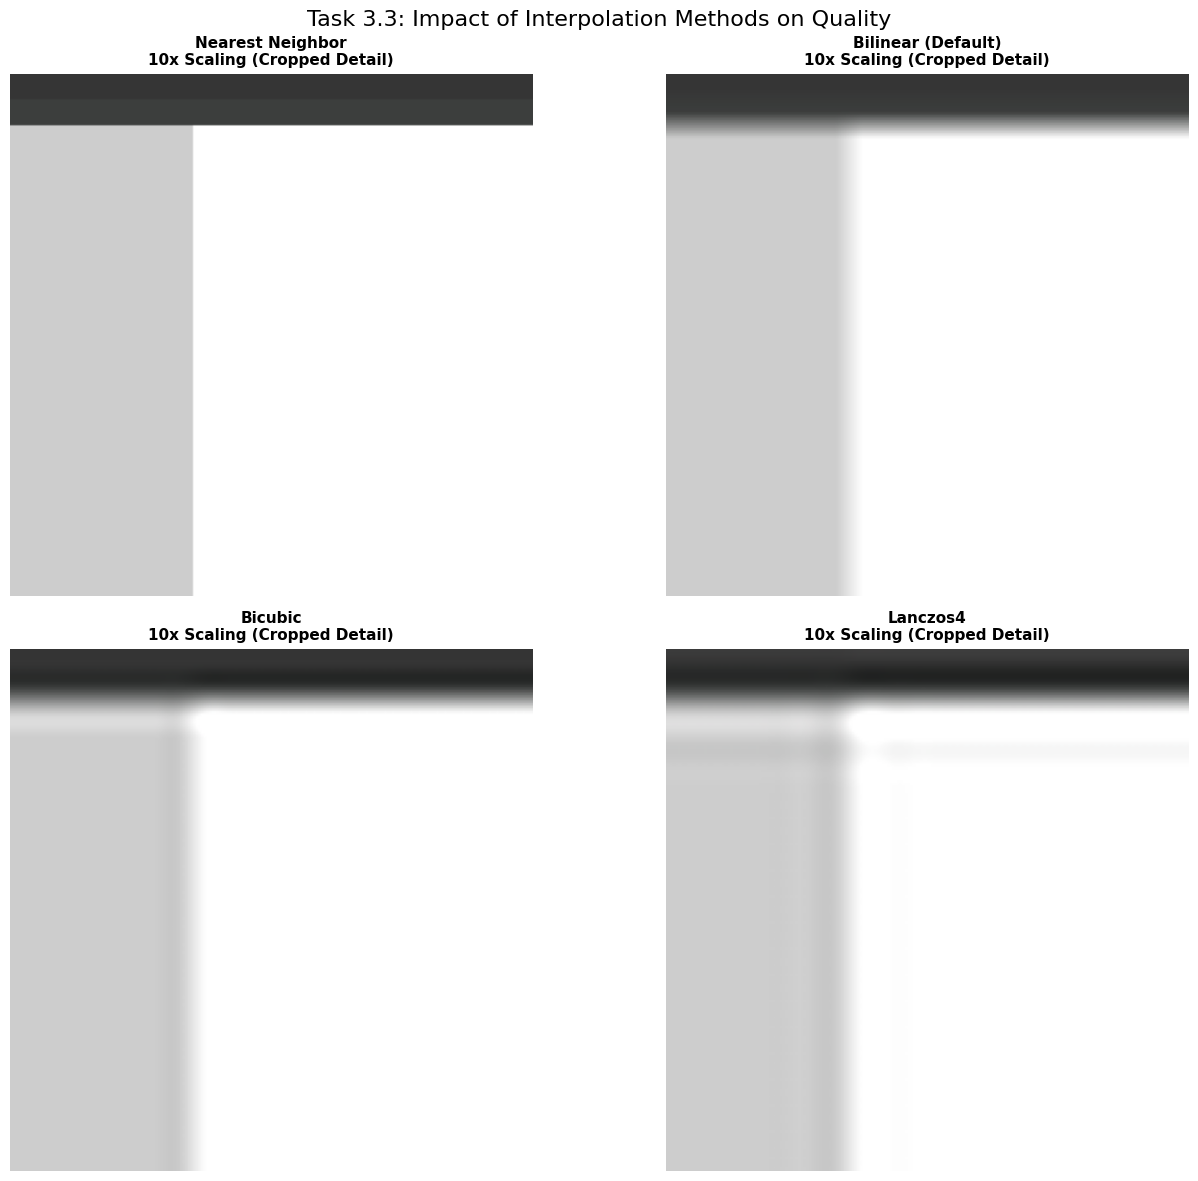

Interpolation method comparison completed!


In [12]:
# Task 3.3: Comparison with Different Interpolation Methods
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Task 3.3: Impact of Interpolation Methods on Quality', fontsize=16)

# Test on extreme scaling (10x)
scale_factor = 10
scaling_matrix = np.float32([[scale_factor, 0, 0], [0, scale_factor, 0]])
new_w = int(w * scale_factor)
new_h = int(h * scale_factor)

# Different interpolation methods
interpolation_methods = [
    ("Nearest Neighbor", cv2.INTER_NEAREST),
    ("Bilinear (Default)", cv2.INTER_LINEAR),
    ("Bicubic", cv2.INTER_CUBIC),
    ("Lanczos4", cv2.INTER_LANCZOS4),
]

for idx, (method_name, method_flag) in enumerate(interpolation_methods):
    row = idx // 2
    col = idx % 2
    
    # Use cv2.resize with specific interpolation
    scaled_img = cv2.resize(image, (new_w, new_h), interpolation=method_flag)
    
    # For display, crop to a smaller region to show details
    crop_region = scaled_img[100:300, 100:300]
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(crop_region, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f'{method_name}\n10x Scaling (Cropped Detail)', fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Interpolation method comparison completed!")

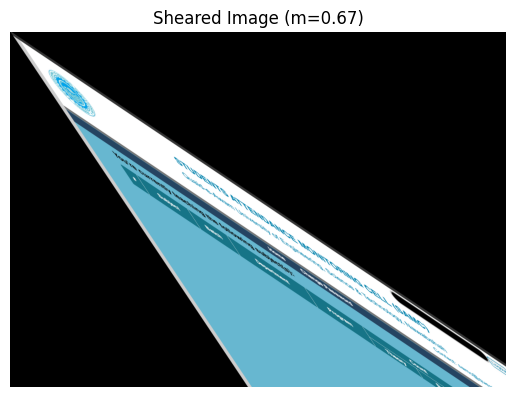

In [13]:
m = 0.67
shearing_matrix = np.float32([[1, m, 0], [m, 1, 0]])
sheared_img = cv2.warpAffine(image, shearing_matrix, (w, h))
plt.imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
plt.title("Sheared Image (m=0.67)")
plt.axis("off")
plt.show()  


# Task 4: Shearing Transformations - Distortion and Proportion Analysis

This section explores shearing transformations along different axes with varying factors to understand how shearing distorts images and affects their proportions.

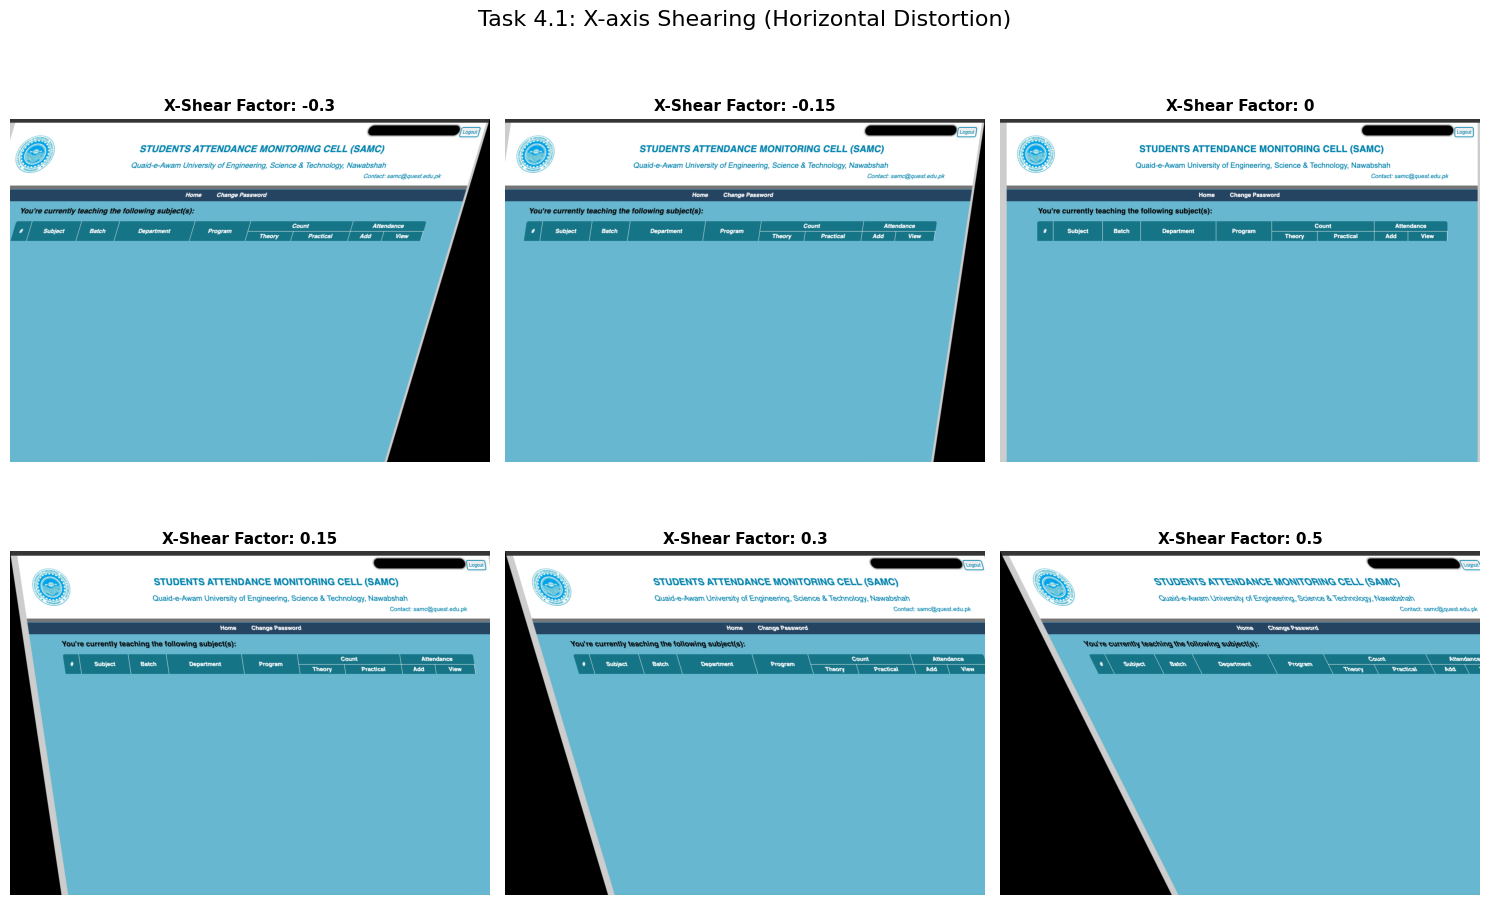

X-axis shearing completed!


In [14]:
# Task 4.1: X-axis Shearing with Different Factors
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task 4.1: X-axis Shearing (Horizontal Distortion)', fontsize=16)

# Define different shear factors for x-axis
x_shear_factors = [-0.3, -0.15, 0, 0.15, 0.3, 0.5]

for idx, m_x in enumerate(x_shear_factors):
    row = idx // 3
    col = idx % 3
    
    # Create shearing matrix for x-axis
    # Matrix: [[1, m_x, 0], [0, 1, 0]]
    # where m_x is the shear factor for x-axis
    shearing_matrix = np.float32([[1, m_x, 0], [0, 1, 0]])
    
    # Apply shearing
    sheared_img = cv2.warpAffine(image, shearing_matrix, (w, h))
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f'X-Shear Factor: {m_x}', fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("X-axis shearing completed!")

In [ ]:
# Task 4.2: Y-axis Shearing with Different Factors
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task 4.2: Y-axis Shearing (Vertical Distortion)', fontsize=16)

# Define different shear factors for y-axis
y_shear_factors = [-0.3, -0.15, 0, 0.15, 0.3, 0.5]

for idx, m_y in enumerate(y_shear_factors):
    row = idx // 3
    col = idx % 3
    
    # Create shearing matrix for y-axis
    # Matrix: [[1, 0, 0], [m_y, 1, 0]]
    # where m_y is the shear factor for y-axis
    shearing_matrix = np.float32([[1, 0, 0], [m_y, 1, 0]])
    
    # Apply shearing
    sheared_img = cv2.warpAffine(image, shearing_matrix, (w, h))
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(f'Y-Shear Factor: {m_y}', fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Y-axis shearing completed!")

In [ ]:
# Task 4.3: Combined X and Y Shearing
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Task 4.3: Combined X and Y Shearing', fontsize=16)

# Different combinations of shear factors
combined_shears = [
    ("X-Shear: 0.3, Y-Shear: 0", np.float32([[1, 0.3, 0], [0, 1, 0]])),
    ("X-Shear: 0, Y-Shear: 0.3", np.float32([[1, 0, 0], [0.3, 1, 0]])),
    ("X-Shear: 0.2, Y-Shear: 0.2", np.float32([[1, 0.2, 0], [0.2, 1, 0]])),
    ("X-Shear: 0.3, Y-Shear: -0.2", np.float32([[1, 0.3, 0], [-0.2, 1, 0]])),
]

for idx, (title, shear_matrix) in enumerate(combined_shears):
    row = idx // 2
    col = idx % 2
    
    # Apply shearing
    sheared_img = cv2.warpAffine(image, shear_matrix, (w, h))
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Combined shearing completed!")

## Analysis: How Shearing Distorts Images and Affects Proportions

### Understanding the Shearing Transformation

**Shearing Matrix Format:**
- For X-axis shearing: `[[1, m_x, 0], [0, 1, 0]]`
- For Y-axis shearing: `[[1, 0, 0], [m_y, 1, 0]]`
- Where m_x and m_y are shear factors (typically between -1 and 1)

### Key Effects of Shearing:

#### 1. **X-Axis Shearing (Horizontal Distortion)**
- Shifts pixels horizontally based on their vertical position
- **Negative factor (< 0):** Image tilts to the right
- **Positive factor (> 0):** Image tilts to the left
- Vertical lines become diagonal lines at an angle
- Width of image increases with larger shear factors
- Aspect ratio changes: height stays same, width increases

#### 2. **Y-Axis Shearing (Vertical Distortion)**
- Shifts pixels vertically based on their horizontal position
- **Negative factor (< 0):** Image tilts downward
- **Positive factor (> 0):** Image tilts upward
- Horizontal lines become diagonal lines at an angle
- Height of image increases with larger shear factors
- Aspect ratio changes: width stays same, height increases

#### 3. **Proportion Distortion**
- **Shape distortion:** Rectangles become parallelograms
- **Area change:** Image bounding box area increases but original content area remains constant
- **No scaling of pixels:** Unlike scaling, individual pixels don't change size (no pixelation)
- **Rotation-like effect:** Creates an "italic" or "skewed" appearance
- **Directional deformation:** Direction and magnitude of distortion depend on shear factor sign and value

#### 4. **Combined X and Y Shearing**
- When both axes are sheared, the effect is more complex
- Can create perspectives or 3D-like distortions
- Useful for perspective correction and image warping
- Opposite signs in X and Y shearing can partially cancel effects

#### 5. **Comparison with Other Transformations**

| Aspect | Rotation | Scaling | Shearing |
|--------|----------|---------|----------|
| Aspect Ratio | Preserved | Preserved | **Changed** |
| Angles | Changed | Same | **Changed** |
| Straight Lines | Preserved | Preserved | **Preserved** |
| Pixel Size | Same | **Changed** | Same |
| Center | Can rotate | Scales equally | Shifts differentially |

#### 6. **Practical Applications of Shearing**
- **Perspective correction:** Correct skewed document scans
- **Italic text creation:** Apply shearing to normal fonts
- **3D effects:** Simulate 3D rotations
- **Artistic effects:** Create stylized or distorted images
- **Document warping:** Correct camera angle distortions

#### 7. **Extreme Shearing Effects**
- Very large shear factors (e.g., > 1) create severe distortions
- Information can be compressed into narrow areas
- Some parts of the image may extend beyond canvas
- Negative and positive combinations can create complex shapes
- Quality is generally preserved (no pixel interpolation artifacts)

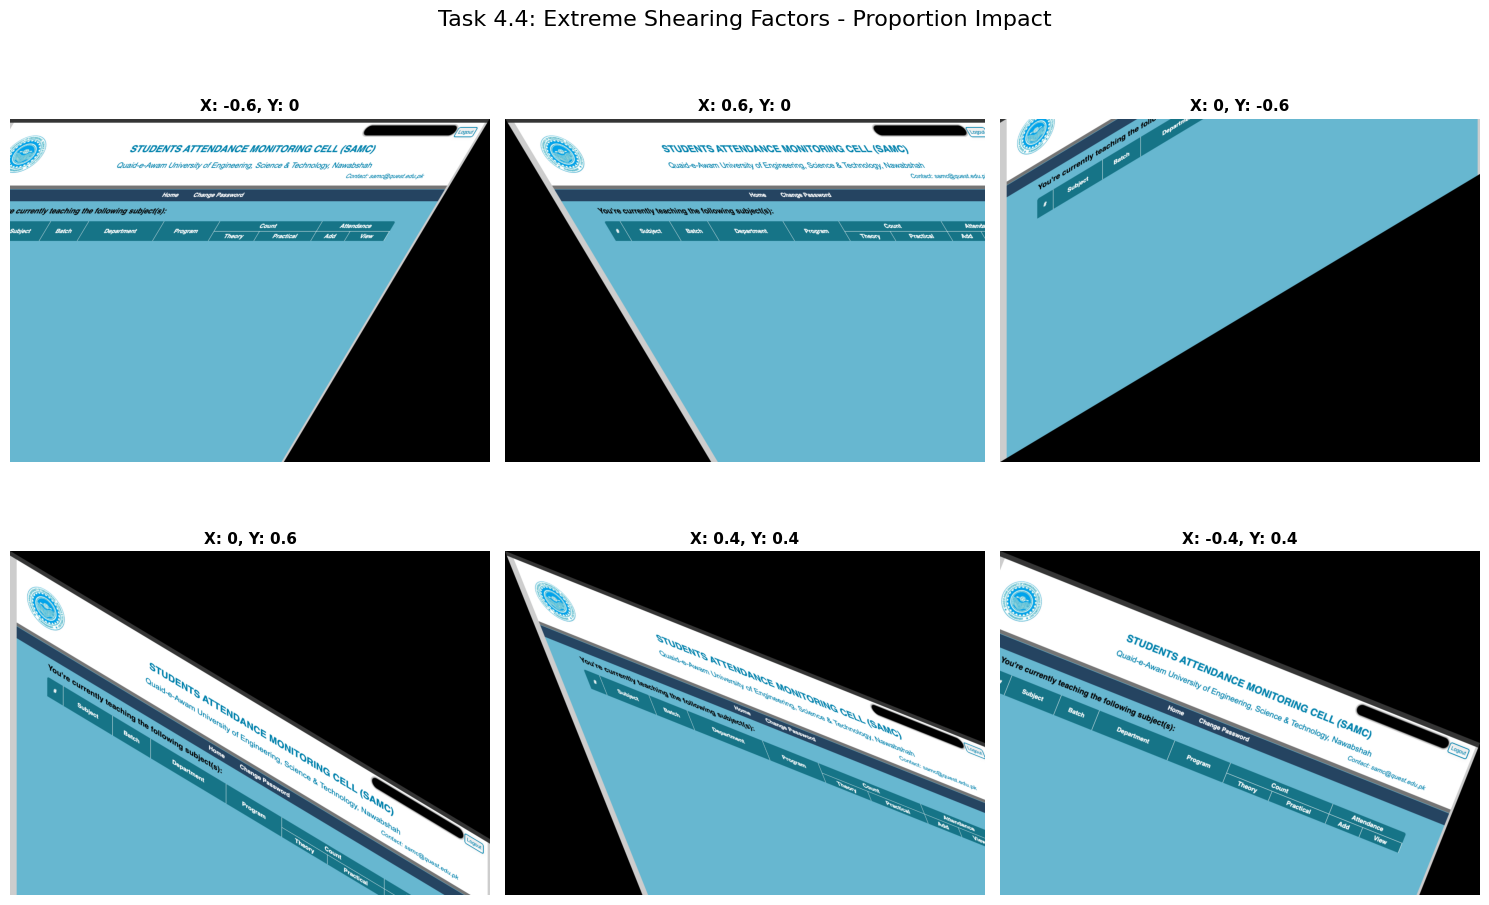

Extreme shearing analysis completed!


In [15]:
# Task 4.4: Extreme Shearing and Proportion Analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Task 4.4: Extreme Shearing Factors - Proportion Impact', fontsize=16)

# Extreme shear factors
extreme_shear_factors = [
    ("X: -0.6, Y: 0", np.float32([[1, -0.6, 0], [0, 1, 0]])),
    ("X: 0.6, Y: 0", np.float32([[1, 0.6, 0], [0, 1, 0]])),
    ("X: 0, Y: -0.6", np.float32([[1, 0, 0], [-0.6, 1, 0]])),
    ("X: 0, Y: 0.6", np.float32([[1, 0, 0], [0.6, 1, 0]])),
    ("X: 0.4, Y: 0.4", np.float32([[1, 0.4, 0], [0.4, 1, 0]])),
    ("X: -0.4, Y: 0.4", np.float32([[1, -0.4, 0], [0.4, 1, 0]])),
]

for idx, (title, shear_matrix) in enumerate(extreme_shear_factors):
    row = idx // 3
    col = idx % 3
    
    # Apply shearing
    sheared_img = cv2.warpAffine(image, shear_matrix, (w, h))
    
    # Display
    axes[row, col].imshow(cv2.cvtColor(sheared_img, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(title, fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Extreme shearing analysis completed!")

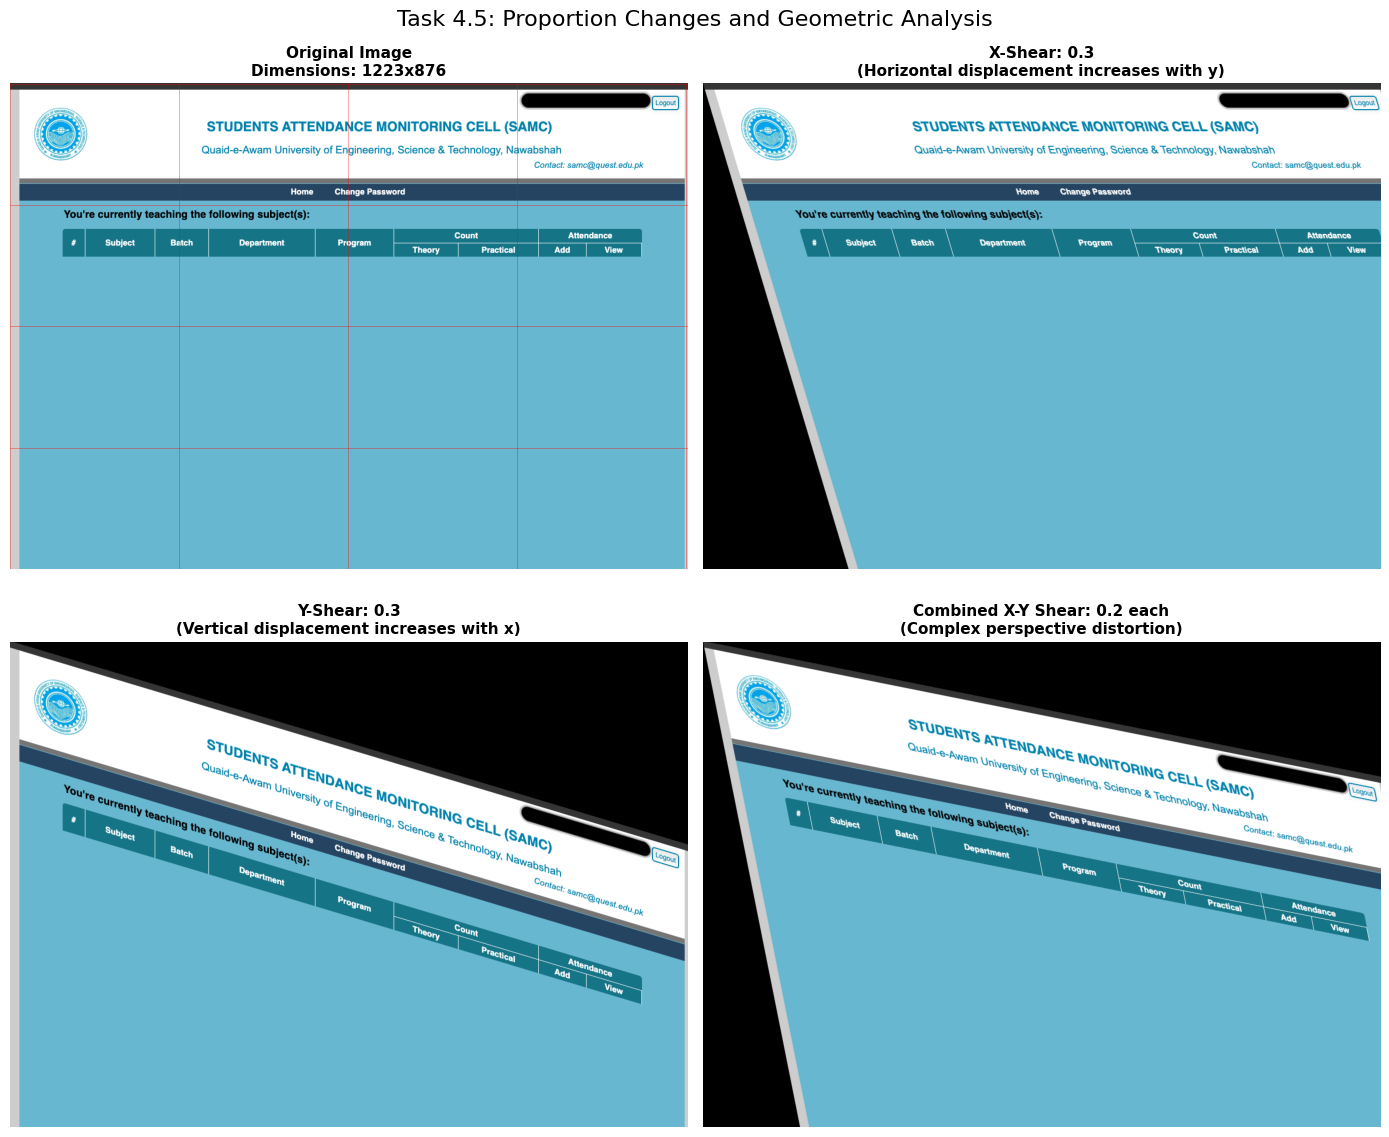


=== Proportion Analysis ===
Original dimensions: 1223x876
Original aspect ratio: 1.40

With X-shear of 0.3:
  - Vertical lines rotate, become diagonal
  - Width effectively increases due to angle
  - Height remains the same

With Y-shear of 0.3:
  - Horizontal lines rotate, become diagonal
  - Height effectively increases due to angle
  - Width remains the same

With combined shearing:
  - Both axes distorted simultaneously
  - Creates complex 3D-like perspective
  - Proportions changed in both dimensions


In [17]:
# Task 4.5: Quantitative Analysis - Measuring Proportion Changes
import matplotlib.patches as patches

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Task 4.5: Proportion Changes and Geometric Analysis', fontsize=16)

# Original image with grid overlay
axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
# Add grid reference
for i in range(0, w, w//4):
    axes[0, 0].axvline(i, color='red', linewidth=0.5, alpha=0.5)
for i in range(0, h, h//4):
    axes[0, 0].axhline(i, color='red', linewidth=0.5, alpha=0.5)
axes[0, 0].set_title(f'Original Image\nDimensions: {w}x{h}', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# X-shearing example
shear_x_matrix = np.float32([[1, 0.3, 0], [0, 1, 0]])
sheared_x = cv2.warpAffine(image, shear_x_matrix, (w, h))
axes[0, 1].imshow(cv2.cvtColor(sheared_x, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('X-Shear: 0.3\n(Horizontal displacement increases with y)', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# Y-shearing example
shear_y_matrix = np.float32([[1, 0, 0], [0.3, 1, 0]])
sheared_y = cv2.warpAffine(image, shear_y_matrix, (w, h))
axes[1, 0].imshow(cv2.cvtColor(sheared_y, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Y-Shear: 0.3\n(Vertical displacement increases with x)', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

# Combined shearing
shear_combined = np.float32([[1, 0.2, 0], [0.2, 1, 0]])
sheared_combined = cv2.warpAffine(image, shear_combined, (w, h))
axes[1, 1].imshow(cv2.cvtColor(sheared_combined, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Combined X-Y Shear: 0.2 each\n(Complex perspective distortion)', fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n=== Proportion Analysis ===")
print(f"Original dimensions: {w}x{h}")
print(f"Original aspect ratio: {w/h:.2f}")
print(f"\nWith X-shear of 0.3:")
print(f"  - Vertical lines rotate, become diagonal")
print(f"  - Width effectively increases due to angle")
print(f"  - Height remains the same")
print(f"\nWith Y-shear of 0.3:")
print(f"  - Horizontal lines rotate, become diagonal")
print(f"  - Height effectively increases due to angle")
print(f"  - Width remains the same")
print(f"\nWith combined shearing:")
print(f"  - Both axes distorted simultaneously")
print(f"  - Creates complex 3D-like perspective")
print(f"  - Proportions changed in both dimensions")